# Program - 

**Purpose**


**Content**
- read data
- plot XY profiles

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 

**Reference program:**



In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


# Functions

## theta_l_to_T_qv_ql

In [2]:
# Constants
Rd = 287.04       # gas constant for dry air (J/kg/K)
Rv = 461.5        # gas constant for water vapor (J/kg/K)
Cp = 1005.7       # specific heat of dry air at constant pressure (J/kg/K)
Lv = 2.5e6        # latent heat of vaporization (J/kg)
epsilon = Rd / Rv

def saturation_vapor_pressure(T):
    """Calculate saturation vapor pressure over liquid water (Pa)"""
    return 610.94 * np.exp((17.625 * (T - 273.15)) / (T - 30.11))

def saturation_specific_humidity(p, T):
    """Compute saturation specific humidity (kg/kg)"""
    e_s = saturation_vapor_pressure(T)
    return epsilon * e_s / (p - (1 - epsilon) * e_s)

def theta_l_to_T_qv_ql(theta_l, q_t, p, tol=1e-6, max_iter=100):
    """
    Convert theta_l and q_t to T, q_v, and q_l using iterative saturation adjustment.

    Parameters:
        theta_l: liquid water potential temperature (K)
        q_t: total water mixing ratio (kg/kg)
        p: pressure (Pa)

    Returns:
        T: temperature (K)
        q_v: specific humidity (kg/kg)
        q_l: liquid water mixing ratio (kg/kg)
    """
    # Initial guess for T (assume no liquid water)
    T = theta_l * (p / 1e5) ** (Rd / Cp)
    
    for _ in range(max_iter):
        q_vs = saturation_specific_humidity(p, T)
        q_v = np.minimum(q_t, q_vs)
        q_l = np.maximum(q_t - q_vs, 0.0)
        
        # Compute updated T based on theta_l
        T_new = theta_l * (p / 1e5) ** (Rd / Cp) + (Lv / Cp) * q_l
        
        if np.all(np.abs(T_new - T) < tol):
            break
        T = T_new

    return T, q_v, q_l

## plot_profiles

In [3]:
def plot_profiles (axes, fields, z, lg_label):

    # Define a dictionary for colors
    colors = {
        'theta_l': 'blue',
        'q_t': 'green',
        'u': 'purple',
        'v': 'orange'
    }
    
    # Loop through the fields and plot
    for i, (key, field) in enumerate(fields.items()):
        color = colors.get(key, 'red')  # Default to black if key not in colors
        axes[i].plot(field['data'], z, color=color, label=lg_label)
        axes[i].set_xlabel(field['label'])
        axes[i].set_title(field['title'])
        #axes[i].invert_yaxis()  # Reverse the y-axis (height)
        axes[i].grid(True)
        axes[i].legend()  # Add legend to each subplot

    plt.tight_layout()
    plt.show()

## RF01_IC_formula
Stevens, B., Moeng, C.-H., Ackerman, A. S., Bretherton, C. S., Chlond, A., de Roode, S., Edwards, J., Golaz, J. C., Jiang, H., Khairoutdinov, M., Kirkpatrick, M. P., Lewellen, D. C., Lock, A., Müller, F., Stevens, D. E., Whelan, E., & Zhu, P. (2005). Evaluation of large-eddy simulations via observations of nocturnal marine stratocumulus. Monthly Weather Review, 133(6), 1443–1462. https://doi.org/10.1175/MWR2930.1

In [4]:
def RF01_IC_formula(z, z_i, p_surface=1017.8e2):
    """
    Compute theta_l, q_t, u, v, T, q_v, q_l profiles based on height array z and inversion height z_i.
    
    Parameters:
        z (array-like): 1D array of height values (in meters).
        z_i (float): Inversion height (in meters).
        p_surface (float): Surface pressure (in hPa).
        
    Returns:
        dict: Dictionary with keys 'theta_l', 'q_t', 'u', 'v', 'T', 'q_v', 'q_l'.
    """
    z = np.asarray(z)
    
    # Initialize theta_l with default value
    theta_l = np.full_like(z, 289.0, dtype=np.float64)
    above_zi = z > z_i
    theta_l[above_zi] = 297.5 + (z[above_zi] - z_i) ** (1/3)

    # Compute q_t
    q_t = np.where(z <= z_i, 9.0, 1.5)  # g/kg

    # Constant wind profiles
    u = np.full_like(z, 6.0)       # m/s
    v = np.full_like(z, -4.25)     # m/s

    # Convert z (height) to pressure (p) using the hypsometric equation
    R = 287.05  # specific gas constant for dry air (J/kg·K)
    g = 9.81    # gravitational acceleration (m/s²)
    L = 2.5e6   # Latent heat of vaporization (J/kg)
    M = 28.97   # Molar mass of air (kg/mol)
    T_surface = 290.0  # Surface temperature (in Kelvin, example)

    #p = p_surface * (1 - (L * z) / (R * T_surface)) ** (g * M / (R * L))  # Pressure calculation
    # Now, compute temperature and mixing ratios (q_v, q_l) from theta_l and q_t
    # Assuming theta_l_to_T_qv_ql function exists and works properly:
    #T, q_v, q_l = theta_l_to_T_qv_ql(theta_l, q_t, p)
    T = np.full_like(z, 0)  
    q_v = np.full_like(z, 0)  
    q_l = np.full_like(z, 0)  
    
    return {
        'theta_l': {
            'data': theta_l,
            'label': r'$\theta_l$ (K)',
            'title': 'Liquid Water Potential Temperature'
        },
        'q_t': {
            'data': q_t,
            'label': r'$q_t$ (g kg$^{-1}$)',
            'title': 'Total Water Mixing Ratio'
        },
        'u': {
            'data': u,
            'label': r'$U$ (m/s)',
            'title': 'Zonal Wind (U)'
        },
        'v': {
            'data': v,
            'label': r'$V$ (m/s)',
            'title': 'Meridional Wind (V)'
        },
        'T': {
            'data': T,
            'label': r'$T$ (K)',
            'title': 'Temperature'
        },
        'q_v': {
            'data': q_v,
            'label': r'$q_v$ (g/kg)',
            'title': 'Water Vapor Mixing Ratio'
        },
        'q_l': {
            'data': q_l,
            'label': r'$q_l$ (g/kg)',
            'title': 'Liquid Water Mixing Ratio'
        }
    }

# Example usage:
z = np.linspace(0, 2000, 500)
z_i = 840  # Inversion height
p_surface = 1013.25  # Surface pressure (in hPa)
fields = RF01_IC_formula(z, z_i, p_surface)


## plot_profiles

In [5]:
def plot_profiles (axes, fields, z, lg_label):

    # Define a dictionary for colors
    colors = {
        'theta_l': 'blue',
        'q_t': 'green',
        'u': 'purple',
        'v': 'orange'
    }
    
    # Loop through the fields and plot
    for i, (key, field) in enumerate(fields.items()):
        color = colors.get(key, 'red')  # Default to black if key not in colors
        axes[i].plot(field['data'], z, color=color, label=lg_label)
        axes[i].set_xlabel(field['label'])
        axes[i].set_title(field['title'])
        #axes[i].invert_yaxis()  # Reverse the y-axis (height)
        axes[i].grid(True)
        axes[i].legend()  # Add legend to each subplot

    plt.tight_layout()
    plt.show()

# RF01

## RF01 SCM 

In [6]:
filename = "./DYCOMSrf01_4day_4scam.nc"
ds_scm = xr.open_dataset(filename)

# Print all variable names and their values
do_print = False
for var_name in ds_scm.data_vars:
    if (do_print):
        print(f"Variable: {var_name}")
        print(ds_scm[var_name].values)
        print("-" * 40)  # Separator for better readability

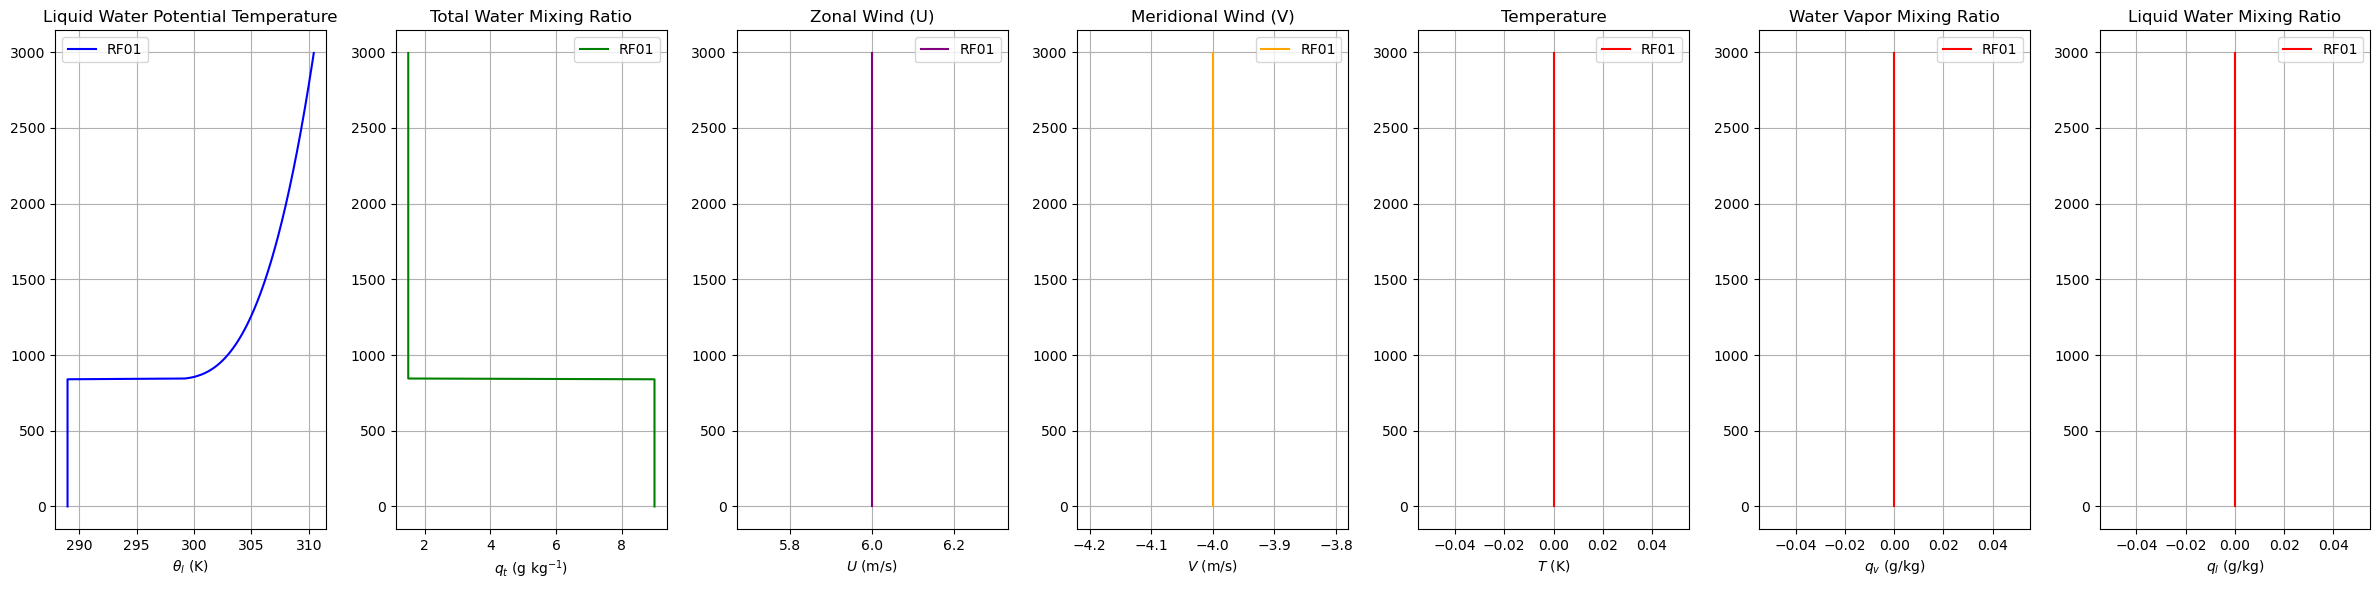

In [12]:
# Height array
#z = np.linspace(0, 3000, 601)
z = np.arange(0,3000,5)

z_i = 840  # Inversion height

# Get the fields dictionary
fields = RF01_IC_formula(z, z_i)

num_keys = len(fields)

# Create a figure with 4 subplots
fig, axes = plt.subplots(1, num_keys, figsize=(24, 6))

plot_profiles (axes, fields, z, lg_label="RF01")
#fields